<a href="https://colab.research.google.com/github/theiceman07/FastF1-Undercut-Analyzer-/blob/main/FastF1_%E2%80%9CUndercut_Analyzer%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core         

[auto] Selected: Round 24 – Abu Dhabi Grand Prix (2024-12-08)
Session selection failed ('Event' object has no attribute 'Year'). Falling back to 2024 Bahrain Race.


req            INFO 	Using cached data for car_data
INFO:fastf1.fastf1.req:Using cached data for car_data
req            INFO 	Using cached data for position_data
INFO:fastf1.fastf1.req:Using cached data for position_data
req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


Event: Bahrain Grand Prix | Round 1 | Date: 2024-03-02 15:00:00 | Session: Race
Showing columns: ['Position', 'Abbreviation', 'TeamName', 'Status', 'Points', 'GridPosition', 'Time']


,Position,Abbreviation,TeamName,Status,Points,GridPosition,Time
0,1.0,VER,Red Bull Racing,Finished,26.0,1.0,0 days 01:31:44.742000
1,2.0,PER,Red Bull Racing,Finished,18.0,5.0,0 days 00:00:22.457000
2,3.0,SAI,Ferrari,Finished,15.0,4.0,0 days 00:00:25.110000
3,4.0,LEC,Ferrari,Finished,12.0,2.0,0 days 00:00:39.669000
4,5.0,RUS,Mercedes,Finished,10.0,3.0,0 days 00:00:46.788000
5,6.0,NOR,McLaren,Finished,8.0,7.0,0 days 00:00:48.458000
6,7.0,HAM,Mercedes,Finished,6.0,9.0,0 days 00:00:50.324000
7,8.0,PIA,McLaren,Finished,4.0,8.0,0 days 00:00:56.082000
8,9.0,ALO,Aston Martin,Finished,2.0,6.0,0 days 00:01:14.887000
9,10.0,STR,Aston Martin,Finished,1.0,12.0,0 days 00:01:33.216000



Tyre stints summary:


,Driver,DriverNumber,Stint,Compound,StintLength
0,ALB,23,1.0,SOFT,15
1,ALB,23,2.0,HARD,21
2,ALB,23,3.0,HARD,20
3,ALO,14,1.0,SOFT,15
4,ALO,14,2.0,HARD,26
...,...,...,...,...,...
58,VER,1,2.0,HARD,20
59,VER,1,3.0,SOFT,20
60,ZHO,24,1.0,SOFT,9
61,ZHO,24,2.0,HARD,19


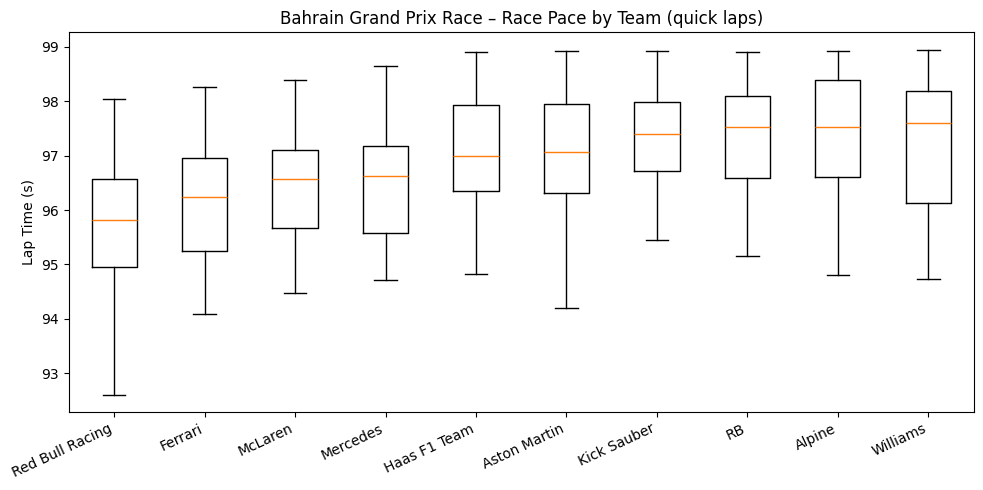

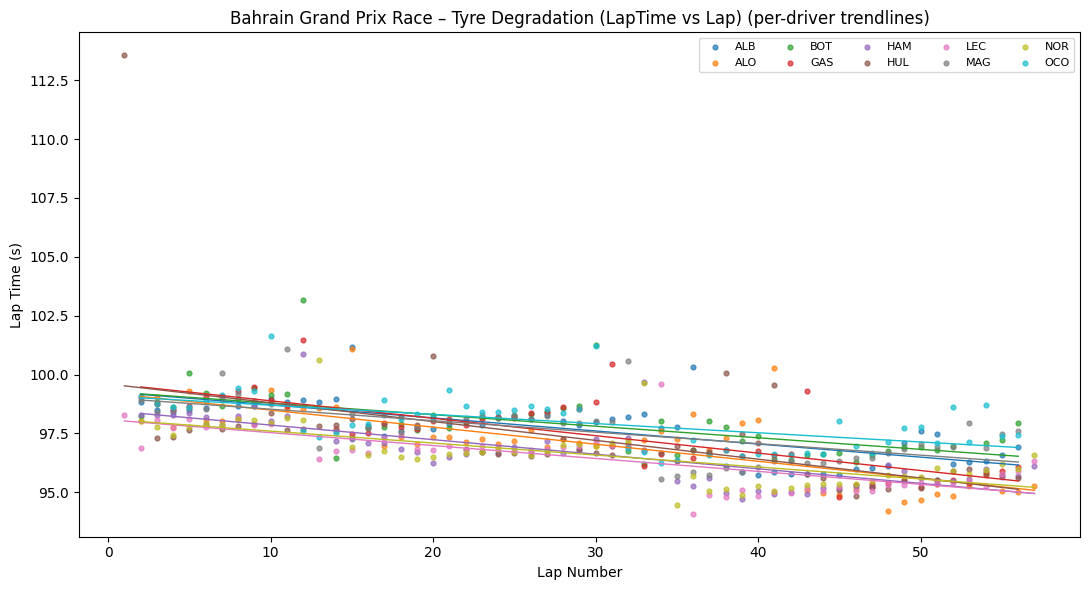


Potential battle detected: STR (pit L9) vs ZHO (pit L9) within ±3 laps.


,LapNumber,STR_LapTime_s,STR_Position,ZHO_LapTime_s,ZHO_Position,Delta_s_(d1-d2)
0,6,98.925,18,98.488,13,0.437
1,7,98.769,18,99.517,13,-0.748
2,8,98.857,18,99.646,13,-0.789
3,9,102.112,19,101.849,16,0.263
4,10,117.815,18,119.328,17,-1.513
5,11,96.494,17,96.365,16,0.129
6,12,97.175,16,96.995,15,0.180


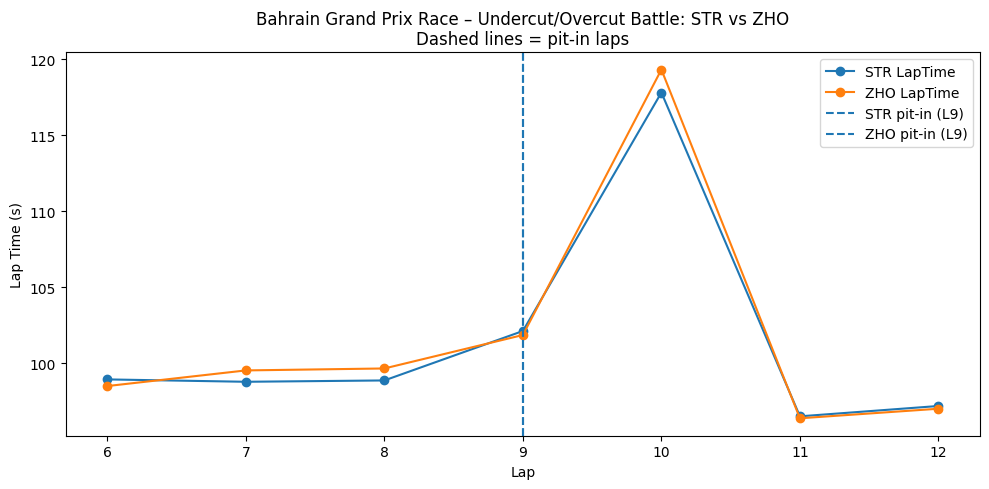

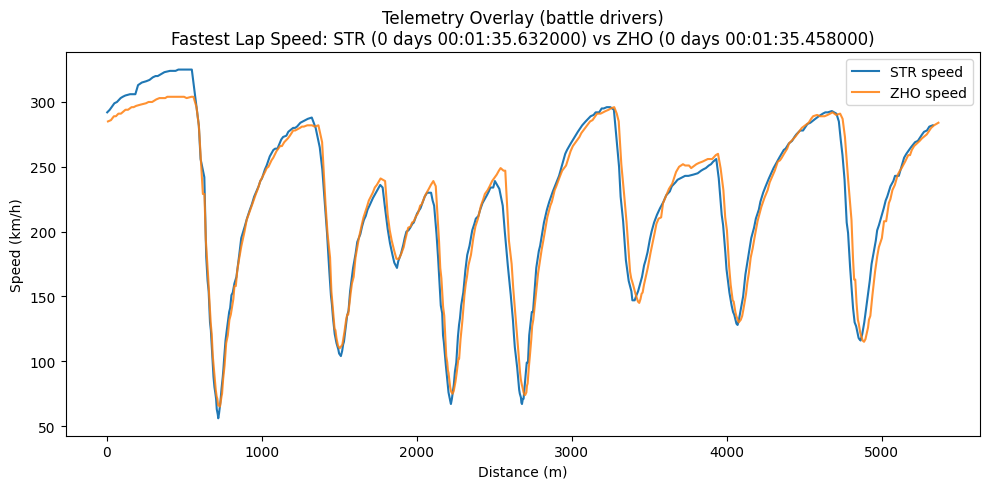

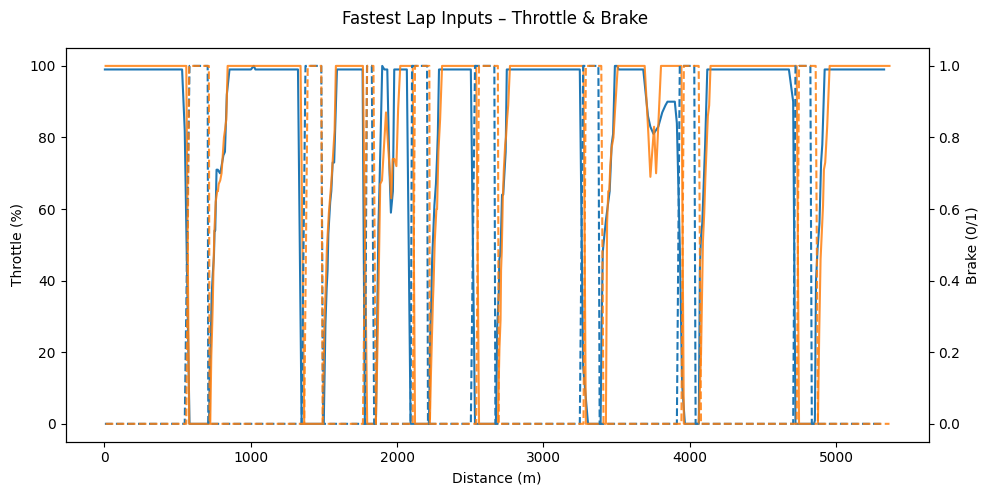


Done ✅ — tweak PARAMS at the top (e.g., set STRATEGY='by_name' and pick a GP) and re-run.


In [6]:
# ============================================================
# FastF1 Colab Project: "Undercut Analyzer" (robust & unique)
# Single-cell, copy-paste ready
# ============================================================

# 0) Install
!pip -q install fastf1 pandas matplotlib numpy

# 1) Imports & setup
import os, time, warnings
from typing import Optional, Tuple, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fastf1
from fastf1 import plotting
from fastf1.core import Laps

warnings.filterwarnings("ignore")

# 2) User-tweakable parameters
PARAMS = {
    # Selection strategy:
    #   "auto"     -> latest completed race in YEAR
    #   "by_name"  -> set YEAR + GRAND_PRIX (partial name ok, e.g., "Monza")
    #   "by_round" -> set YEAR + ROUND (1..22)
    "STRATEGY": "auto",

    "YEAR": 2024,
    "GRAND_PRIX": "Bahrain",   # used only if STRATEGY="by_name"
    "ROUND": 1,                # used only if STRATEGY="by_round"

    "SESSION": "R",            # "R", "Q", "SQ", "S", "FP1/2/3"

    # Cleaning knobs
    "LAPTIME_MIN_S": 50,       # drop absurdly fast/glitch laps
    "OUTLIER_Q": 0.99,         # remove top 1% slow laps in quick-lap set

    # Analysis knobs
    "MAX_TELEMETRY_DRIVERS": 2,
    "PIT_WINDOW_LAPS": 3       # consider pit stops within ±N laps an undercut battle
}

# 3) Cache (faster & more reliable)
CACHE_DIR = "/content/f1cache"
os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

# 4) Matplotlib defaults from FastF1
plotting.setup_mpl(mpl_timedelta_support=True, misc_mpl_mods=False)

# 5) Helpers
def choose_session(params: dict):
    """Load and return a FastF1 session according to the chosen strategy, with retries and fallbacks."""
    year = int(params["YEAR"])
    sess_code = params["SESSION"]

    try:
        if params["STRATEGY"] == "auto":
            sch = fastf1.get_event_schedule(year, include_testing=False)

            # ---- robust timezone-naive comparison to 'now' ----
            sch["EventDate"] = pd.to_datetime(sch["EventDate"], utc=True).dt.tz_localize(None)
            now = pd.Timestamp.utcnow().tz_localize(None)

            completed = sch[sch["EventDate"] < now].sort_values("RoundNumber")
            event = completed.iloc[-1] if not completed.empty else sch.sort_values("RoundNumber").iloc[-1]
            print(f"[auto] Selected: Round {int(event.RoundNumber)} – {event.EventName} ({event.EventDate.date()})")
            s = fastf1.get_session(int(event.Year), int(event.RoundNumber), sess_code)

        elif params["STRATEGY"] == "by_round":
            print(f"[by_round] {year} Round {int(params['ROUND'])}")
            s = fastf1.get_session(year, int(params["ROUND"]), sess_code)

        else:  # by_name (partial ok)
            gp = str(params["GRAND_PRIX"]).strip().lower()
            sch = fastf1.get_event_schedule(year, include_testing=False)
            matches = sch[sch["EventName"].str.lower().str.contains(gp, na=False)]
            if matches.empty:
                raise ValueError(f"No GP like '{params['GRAND_PRIX']}' found in {year}.")
            event = matches.iloc[0]
            print(f"[by_name] Matched: Round {int(event.RoundNumber)} – {event.EventName}")
            s = fastf1.get_session(year, int(event.RoundNumber), sess_code)

        # load with simple retries (network hiccups happen)
        for attempt in range(3):
            try:
                print(f"Loading session (attempt {attempt+1})...")
                s.load()
                return s
            except Exception as e:
                print(f"Load failed: {e}")
                time.sleep(1.5 * (attempt + 1))

        raise RuntimeError("Failed to load session after retries.")

    except Exception as e:
        print(f"Session selection failed ({e}). Falling back to 2024 Bahrain Race.")
        s = fastf1.get_session(2024, "Bahrain", "R")
        s.load()
        return s

def clean_laps(laps: Laps, laptime_min_s: float, outlier_q: float) -> Laps:
    """Return robust 'quick' laps using FastF1 helper plus safety filters."""
    quick = laps.pick_quicklaps()
    quick = quick[quick["LapTime"].notna()]
    quick = quick[quick["LapTime"].dt.total_seconds() >= laptime_min_s]
    if len(quick) > 5:
        cutoff = quick["LapTime"].dt.total_seconds().quantile(outlier_q)
        quick = quick[quick["LapTime"].dt.total_seconds() <= cutoff]
    if "IsAccurate" in quick.columns:
        quick = quick[(quick["IsAccurate"].isna()) | (quick["IsAccurate"] == True)]
    return quick

def stint_summary(laps: Laps) -> pd.DataFrame:
    df = (laps[["Driver", "DriverNumber", "Stint", "Compound", "LapNumber"]]
          .dropna(subset=["Stint", "Compound"]))
    return (df.groupby(["Driver", "DriverNumber", "Stint", "Compound"], as_index=False)
              .agg(StintLength=("LapNumber", "count"))
              .sort_values(["Driver", "Stint"]))

def team_pace_boxplot(clean: Laps, results_df: pd.DataFrame, title: str):
    drv_to_team = {r["Abbreviation"]: r["TeamName"] for _, r in results_df.iterrows() if "Abbreviation" in results_df.columns}
    df = clean.copy()
    df["LapTime_s"] = df["LapTime"].dt.total_seconds()
    df["TeamName"] = df["Driver"].map(lambda d: drv_to_team.get(d, "Unknown"))
    order = (df.groupby("TeamName")["LapTime_s"].median().sort_values().index.tolist())
    data = [df.loc[df["TeamName"] == t, "LapTime_s"] for t in order]

    plt.figure(figsize=(10,5))
    plt.boxplot(data, labels=order, showfliers=False)
    plt.title(title)
    plt.ylabel("Lap Time (s)")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

def tyre_deg_plot(laps: Laps, title: str):
    df = laps[["Driver", "Stint", "LapNumber", "LapTime", "Compound"]].dropna()
    df = df[df["LapTime"].notna()].copy()
    df["LapTime_s"] = df["LapTime"].dt.total_seconds()

    # trim outliers per driver-stint
    trimmed = []
    for (d, s), g in df.groupby(["Driver", "Stint"]):
        q_hi = g["LapTime_s"].quantile(0.98)
        trimmed.append(g[g["LapTime_s"] <= q_hi])
    df = pd.concat(trimmed, ignore_index=True)

    drivers = df["Driver"].unique().tolist()[:10]  # keep readable
    plt.figure(figsize=(11,6))
    for d in drivers:
        gd = df[df["Driver"] == d]
        plt.scatter(gd["LapNumber"], gd["LapTime_s"], s=12, label=d, alpha=0.7)
        if len(gd) >= 5:
            coef = np.polyfit(gd["LapNumber"], gd["LapTime_s"], 1)
            x = np.linspace(gd["LapNumber"].min(), gd["LapNumber"].max(), 50)
            y = np.polyval(coef, x)
            plt.plot(x, y, linewidth=1)
    plt.title(title + " (per-driver trendlines)")
    plt.xlabel("Lap Number")
    plt.ylabel("Lap Time (s)")
    plt.legend(ncol=5, fontsize=8)
    plt.tight_layout()
    plt.show()

def find_undercut_pair(laps: Laps, pit_window: int) -> Optional[Tuple[str, str, int, int]]:
    pit_info = []
    for drv, g in laps.groupby("Driver"):
        pits = g[g["PitInTime"].notna()][["LapNumber"]]
        for lap in pits["LapNumber"].dropna().astype(int).tolist():
            pit_info.append((drv, lap))
    if not pit_info:
        return None
    pit_info.sort(key=lambda x: x[1])
    for i, (d1, l1) in enumerate(pit_info):
        for j in range(i+1, len(pit_info)):
            d2, l2 = pit_info[j]
            if d1 == d2:
                continue
            if abs(l1 - l2) <= pit_window:
                return (d1, d2, int(l1), int(l2))
    return None

def gap_before_after(laps: Laps, d1: str, d2: str, l1: int, l2: int) -> pd.DataFrame:
    window = range(max(1, min(l1, l2)-3), max(l1, l2)+4)
    rows = []
    for ln in window:
        row = {"LapNumber": ln}
        for d in [d1, d2]:
            dl = laps.pick_driver(d)
            lap = dl.loc[dl["LapNumber"] == ln]
            if not lap.empty and lap.iloc[0]["LapTime"] is not None:
                row[f"{d}_LapTime_s"] = lap.iloc[0]["LapTime"].total_seconds()
                pos_val = lap.iloc[0].get("Position", np.nan)
                row[f"{d}_Position"] = int(pos_val) if pd.notna(pos_val) else np.nan
            else:
                row[f"{d}_LapTime_s"] = np.nan
                row[f"{d}_Position"] = np.nan
        rows.append(row)
    df = pd.DataFrame(rows)
    df["Delta_s_(d1-d2)"] = df[f"{d1}_LapTime_s"] - df[f"{d2}_LapTime_s"]
    return df

def plot_undercut_timeline(df: pd.DataFrame, d1: str, d2: str, l1: int, l2: int, title: str):
    plt.figure(figsize=(10,5))
    plt.plot(df["LapNumber"], df[f"{d1}_LapTime_s"], marker="o", label=f"{d1} LapTime")
    plt.plot(df["LapNumber"], df[f"{d2}_LapTime_s"], marker="o", label=f"{d2} LapTime")
    plt.axvline(l1, linestyle="--", label=f"{d1} pit-in (L{l1})")
    plt.axvline(l2, linestyle="--", label=f"{d2} pit-in (L{l2})")
    plt.title(title + "\nDashed lines = pit-in laps")
    plt.xlabel("Lap")
    plt.ylabel("Lap Time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

def telemetry_overlay(session, drivers: List[str], title: str):
    if not drivers:
        return
    drs = drivers[:PARAMS["MAX_TELEMETRY_DRIVERS"]]
    laps = session.laps.pick_quicklaps()
    fastest = []
    for d in drs:
        try:
            fastest.append((d, laps.pick_driver(d).pick_fastest()))
        except Exception:
            pass
    if len(fastest) < 2:
        return
    (d1, lap1), (d2, lap2) = fastest[0], fastest[1]
    tel1 = lap1.get_car_data().add_distance()
    tel2 = lap2.get_car_data().add_distance()

    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(tel1["Distance"], tel1["Speed"], label=f"{d1} speed")
    ax.plot(tel2["Distance"], tel2["Speed"], label=f"{d2} speed", alpha=0.85)
    ax.set_title(title + f"\nFastest Lap Speed: {d1} ({lap1['LapTime']}) vs {d2} ({lap2['LapTime']})")
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Speed (km/h)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(tel1["Distance"], tel1["Throttle"], label=f"{d1} throttle")
    ax1.plot(tel2["Distance"], tel2["Throttle"], label=f"{d2} throttle", alpha=0.85)
    ax1.set_xlabel("Distance (m)")
    ax1.set_ylabel("Throttle (%)")
    ax2 = ax1.twinx()
    ax2.plot(tel1["Distance"], tel1["Brake"], label=f"{d1} brake", linestyle="--")
    ax2.plot(tel2["Distance"], tel2["Brake"], label=f"{d2} brake", linestyle="--", alpha=0.85)
    ax2.set_ylabel("Brake (0/1)")
    fig.suptitle("Fastest Lap Inputs – Throttle & Brake")
    fig.tight_layout()
    plt.show()

# 6) Load session (robust + cached)
session = choose_session(PARAMS)
print(f"Event: {session.event['EventName']} | Round {session.event['RoundNumber']} | Date: {session.date} | Session: {session.name}")

# 7) Results table (robust to missing columns)
results = session.results.copy()
preferred_cols = [
    "Position", "Abbreviation", "TeamName", "Status", "Points",
    "GridPosition", "Time", "BestLapTime", "BestLapSpeed"
]
available = [c for c in preferred_cols if c in results.columns]
if "Position" in results.columns and "Position" not in available:
    available = ["Position"] + available
print("Showing columns:", available if available else list(results.columns))
try:
    display(results[available].sort_values("Position").reset_index(drop=True))
except Exception:
    display(results.reset_index(drop=True))

# 8) Laps & summaries
laps = session.laps
clean = clean_laps(laps, PARAMS["LAPTIME_MIN_S"], PARAMS["OUTLIER_Q"])

print("\nTyre stints summary:")
display(stint_summary(laps))

# 9) Team pace boxplot
team_pace_boxplot(
    clean,
    results,
    title=f"{session.event['EventName']} {session.name} – Race Pace by Team (quick laps)"
)

# 10) Tyre degradation (per-driver trendlines)
tyre_deg_plot(
    laps,
    title=f"{session.event['EventName']} {session.name} – Tyre Degradation (LapTime vs Lap)"
)

# 11) Undercut/overcut pair detection and analysis
pair = find_undercut_pair(laps, PARAMS["PIT_WINDOW_LAPS"])
if pair:
    d1, d2, l1, l2 = pair
    print(f"\nPotential battle detected: {d1} (pit L{l1}) vs {d2} (pit L{l2}) within ±{PARAMS['PIT_WINDOW_LAPS']} laps.")
    gaps = gap_before_after(laps, d1, d2, l1, l2)
    display(gaps)

    plot_undercut_timeline(
        gaps, d1, d2, l1, l2,
        title=f"{session.event['EventName']} {session.name} – Undercut/Overcut Battle: {d1} vs {d2}"
    )

    telemetry_overlay(session, [d1, d2], title="Telemetry Overlay (battle drivers)")
else:
    print("\nNo pit-window battle found. Showing fastest-lap telemetry for top 2 finishers instead.")
    top2 = results.sort_values("Position").head(2)["Abbreviation"].tolist() if "Position" in results.columns else results.head(2)["Abbreviation"].tolist()
    telemetry_overlay(session, top2, title="Telemetry Overlay (top 2 finishers)")

print("\nDone ✅ — tweak PARAMS at the top (e.g., set STRATEGY='by_name' and pick a GP) and re-run.")
